# TP3 — Attribution multicanal — Lumina & Co

**Cours :** Data Marketing et Analytics — DIA2 — HETIC
**Jour 3, notebook 2/2 :** comparaison first touch vs last touch, et recommandation de modèle d'attribution.

Le notebook `TP3_KPIs_Canaux.ipynb` a montré que `display` et `social` ont un ROAS de 0 — zéro conversion
directe — alors qu'ils portent 65 % du volume de points de contact. Ce notebook explique pourquoi, en regardant
la **position** de chaque canal dans le parcours d'achat, et compare deux façons simples d'attribuer le crédit
d'une vente à un canal : first touch (100 % au premier point de contact) et last touch (100 % au dernier).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

CHANNEL_COLORS = {
    "display": "#8891A5", "social": "#B7A8E8", "affiliate": "#5B4FCF", "retargeting": "#2FB4A6",
    "email": "#4C9BE0", "search_paid": "#E0C23C", "direct": "#E0793C",
}

## Étape 0 — Chargement

In [2]:
touchpoints = pd.read_csv("Lumina & Co - CRM/touchpoints.csv")
transactions = pd.read_csv("Lumina & Co - CRM/transactions.csv")

touchpoints["timestamp"] = pd.to_datetime(touchpoints["timestamp"])
transactions["invoice_date"] = pd.to_datetime(transactions["invoice_date"])
transactions = transactions[~transactions.duplicated(keep="first")].reset_index(drop=True)
transactions["line_total"] = transactions["quantity"] * transactions["unit_price"]

print(f"{len(touchpoints):,} points de contact, {touchpoints['journey_id'].nunique():,} parcours".replace(",", " "))

1 080 897 points de contact  214 897 parcours


## Orientation rapide

### Combien de points de contact par parcours ?

`journey_id` distingue deux populations : les parcours qui aboutissent à un achat (préfixe `conv_`) et ceux qui
n'y aboutissent pas (préfixe `exp_`, pour "exposition" — le prospect a été touché mais n'a jamais acheté).

In [3]:
touchpoints["converting_journey"] = touchpoints["journey_id"].str.startswith("conv_")

print("Répartition des parcours :")
print(touchpoints.drop_duplicates("journey_id")["converting_journey"].value_counts())

n_tp_per_journey = touchpoints.groupby(["journey_id", "converting_journey"])["n_touchpoints"].first()
print("\nNombre moyen de points de contact par parcours, tous parcours confondus :",
      round(n_tp_per_journey.mean(), 2))
print("\nNombre moyen de points de contact par parcours, par groupe :")
print(n_tp_per_journey.groupby("converting_journey").mean().round(2))

Répartition des parcours :
converting_journey
False    120531
True      94366
Name: count, dtype: int64



Nombre moyen de points de contact par parcours, tous parcours confondus : 5.44

Nombre moyen de points de contact par parcours, par groupe :
converting_journey
False    6.00
True     4.72
Name: n_touchpoints, dtype: float64


**214 897 parcours au total, dont 94 366 (44 %) aboutissent à un achat.** Un parcours compte en moyenne
**5,44 points de contact**, un peu moins (**4,72**) pour les parcours qui convertissent — les parcours qui
n'aboutissent pas à un achat ne sont pas forcément plus courts, ils s'arrêtent simplement sans conversion.

**Pour la suite (modèles d'attribution), on ne garde que les 94 366 parcours convertissants** : first touch et
last touch se calculent sur le crédit d'*une vente*, donc uniquement sur les parcours qui en ont généré une. Les
120 531 parcours d'exposition ne génèrent aucun revenu à répartir, mais restent pertinents pour comprendre le
rôle de découverte des canaux (cf. ci-dessous).

### Quels canaux en première position ? Quels canaux juste avant la conversion ?

On regarde d'abord sur **l'ensemble des parcours** (convertis ou non) — c'est la vraie photographie de "qui ouvre
le bal" et "qui ferme la vente" dans le comportement des visiteurs, pas seulement chez ceux qui achètent.

In [4]:
first_all = touchpoints[touchpoints["position"] == 1]
last_all = touchpoints[touchpoints["is_last_before_conversion"] == 1]

print("Canal en 1ère position (tous parcours, %) :")
print(first_all["channel"].value_counts(normalize=True).mul(100).round(1))

print("\nCanal juste avant conversion (tous parcours convertis, %) :")
print(last_all["channel"].value_counts(normalize=True).mul(100).round(1))

Canal en 1ère position (tous parcours, %) :
channel
social         40.5
display        40.5
email           9.5
retargeting     9.4
Name: proportion, dtype: float64

Canal juste avant conversion (tous parcours convertis, %) :
channel
affiliate      28.6
retargeting    23.9
direct         17.8
email          15.2
search_paid    14.5
Name: proportion, dtype: float64


**Deux mondes presque disjoints.** `display` et `social` ouvrent à eux deux **81 %** des parcours (40,5 %
chacun) mais **n'apparaissent jamais** en dernière position avant conversion. À l'inverse, `affiliate` (28,6 %),
`retargeting` (23,9 %), `direct` (17,8 %), `email` (15,2 %) et `search_paid` (14,5 %) se partagent 100 % des
dernières positions, mais sont largement minoritaires en première position. C'est la confirmation directe, au
niveau du parcours, de ce qu'on observait déjà sur les KPIs du premier notebook : **display et social jouent un
rôle de découverte, les 5 autres canaux jouent un rôle de closing.**

**Limite à documenter :** on observe ci-dessous que ~28 % des parcours ont un `n_touchpoints` déclaré supérieur
au nombre de lignes réellement présentes — autrement dit, le tout premier contact de certains parcours n'a pas
été capté par le tracking (cohérent avec le cours : le SEO organique ou le bouche-à-oreille ne laissent pas
toujours de trace exploitable). La distribution "1ère position" ci-dessus ne reflète donc que les parcours dont
le premier contact **a été suivi** — le vrai poids du display/social en première position pourrait être encore
sous-estimé.

In [5]:
min_pos_per_journey = touchpoints.groupby("journey_id")["position"].min()
n_declared = touchpoints.drop_duplicates("journey_id").set_index("journey_id")["n_touchpoints"]
n_actual = touchpoints.groupby("journey_id").size()
gap = (n_declared - n_actual)

print(f"Parcours avec un 1er contact non tracké (position de départ > 1 ou lignes manquantes) : "
      f"{(gap > 0).sum():,} / {len(gap):,} ({(gap > 0).mean()*100:.1f} %)".replace(",", " "))

Parcours avec un 1er contact non tracké (position de départ > 1 ou lignes manquantes) : 59 444 / 214 897 (27.7 %)


## Implémentation des deux modèles heuristiques

- **First touch** : 100 % du crédit (et du revenu) va au premier point de contact observé du parcours.
- **Last touch** : 100 % du crédit va au dernier point de contact avant l'achat — c'est directement le point de
  contact où `converted == 1` dans les données, donc le modèle déjà utilisé implicitement dans
  `TP3_KPIs_Canaux.ipynb`.

On restreint aux 94 366 parcours convertissants et on relie chaque conversion au revenu réel de la facture
(comme dans le premier notebook), pour répartir non seulement le *nombre* de conversions mais aussi la *valeur*
en euros par canal.

In [6]:
invoice_revenue = transactions.groupby("invoice_id")["line_total"].sum()

converting = touchpoints[touchpoints["converting_journey"]].copy()

# Last touch : la ligne où converted == 1 porte directement invoice_id et le canal de closing
last_touch = converting[converting["converted"] == 1].set_index("journey_id").copy()
last_touch["invoice_id"] = last_touch["invoice_id"].astype(int).astype(str)
last_touch["revenue"] = last_touch["invoice_id"].map(invoice_revenue)

# First touch : le point de contact avec la position minimale de chaque parcours convertissant
first_touch = converting.sort_values("position").groupby("journey_id").first().copy()
first_touch["revenue"] = first_touch.index.map(last_touch["revenue"])  # le revenu de la vente, peu importe qui l'a ouverte

total_revenue = last_touch["revenue"].sum()
print(f"Revenu total réparti (parcours convertissants) : {total_revenue:,.0f} €".replace(",", " "))
print(f"First touch : {len(first_touch):,} parcours, revenu mappé : {first_touch['revenue'].notna().sum():,}".replace(",", " "))
print(f"Last touch  : {len(last_touch):,} parcours, revenu mappé : {last_touch['revenue'].notna().sum():,}".replace(",", " "))

Revenu total réparti (parcours convertissants) : 18 401 167 €
First touch : 94 366 parcours  revenu mappé : 94 366
Last touch  : 94 366 parcours  revenu mappé : 94 366


In [7]:
def budget_split(df, label):
    out = df.groupby("channel").agg(n_conversions=("revenue", "count"), revenue=("revenue", "sum"))
    out["%_conversions"] = out["n_conversions"] / out["n_conversions"].sum() * 100
    out["%_revenue"] = out["revenue"] / out["revenue"].sum() * 100
    out.columns = pd.MultiIndex.from_product([[label], out.columns])
    return out

split_first = budget_split(first_touch, "First touch")
split_last = budget_split(last_touch, "Last touch")

comparison = split_first.join(split_last, how="outer").fillna(0)
comparison.round(1)

First touch                                       Last touch                                   
            n_conversions    revenue %_conversions %_revenue n_conversions    revenue %_conversions %_revenue
channel                                                                                                      
affiliate            3665   673204.7           3.9       3.7       26979.0  5312839.5          28.6      28.9
direct               3271   613062.9           3.5       3.3       16803.0  3204530.7          17.8      17.4
display             38733  7554869.8          41.0      41.1           0.0        0.0           0.0       0.0
email                3358   665529.6           3.6       3.6       14355.0  2603316.4          15.2      14.1
retargeting          3558   701362.6           3.8       3.8       22563.0  4455875.2          23.9      24.2
search_paid          3408   675669.5           3.6       3.7       13666.0  2824604.7          14.5      15.4
social              38373  7517467.4          40.7      40.9           0.0        0.0           0.0       0.0

### Répartition du budget par canal, selon le modèle

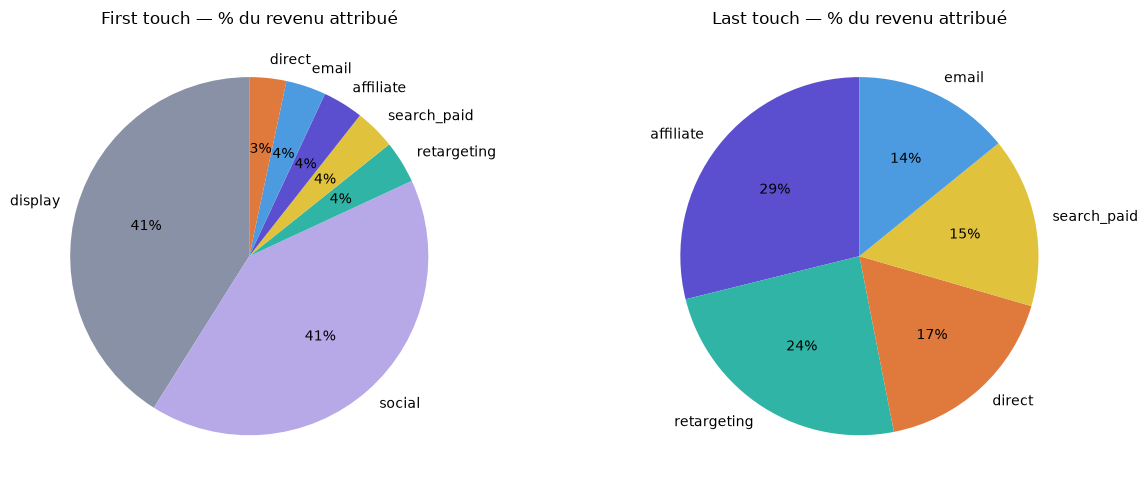

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ft = split_first["First touch"]["%_revenue"].sort_values(ascending=False)
axes[0].pie(ft.values, labels=ft.index, autopct="%1.0f%%", colors=[CHANNEL_COLORS[c] for c in ft.index],
            startangle=90)
axes[0].set_title("First touch — % du revenu attribué")

lt = split_last["Last touch"]["%_revenue"].sort_values(ascending=False)
axes[1].pie(lt.values, labels=lt.index, autopct="%1.0f%%", colors=[CHANNEL_COLORS[c] for c in lt.index],
            startangle=90)
axes[1].set_title("Last touch — % du revenu attribué")

plt.tight_layout()
plt.show()

**Le renversement est total.** En first touch, `display` (41,1 % du revenu) et `social` (40,9 %) captent à
eux deux **82 % du crédit** — cohérent avec leur poids de 81 % en première position observé plus haut. En last
touch, ces deux mêmes canaux tombent à **0 %**, et c'est `affiliate` (28,9 %) et `retargeting` (24,2 %) qui
prennent la tête. Les 5 canaux de closing (affiliate, retargeting, direct, search_paid, email) se partagent
100 % du crédit en last touch contre seulement 18 % en first touch — l'image inverse.

**Si le CMO basait ses décisions budgétaires uniquement sur le last touch**, `display` et `social` seraient
**totalement sous-investis** — au sens propre, un budget alloué proportionnellement au last touch retirerait
tout financement à deux canaux qui pourtant génèrent 81 % des premiers contacts. Couper leur budget romprait la
chaîne de découverte qui alimente ensuite les canaux de closing : sans display/social pour amener de nouveaux
prospects dans le tunnel, `affiliate` et `retargeting` n'auraient personne à reconvertir.

**Est-ce cohérent avec le rôle réel de chaque canal ?** Oui, exactement : `display` et `social` sont des canaux
de **découverte** (larges, peu ciblés, coût par contact très faible — cf. premier notebook, display coûte
0,0047 € par point de contact), alors qu'`affiliate`, `retargeting`, `email` et `search_paid` sont des canaux de
**closing** (ciblés sur un public déjà qualifié — un visiteur retargeté a déjà visité le site, un email est
envoyé à quelqu'un déjà dans la base). Le modèle first touch est cohérent avec le rôle "découverte", le modèle
last touch avec le rôle "closing" — ni l'un ni l'autre seul ne rend justice à l'ensemble du tunnel.

## Réflexion personnelle

**Que peut-on raisonnablement conclure sur la performance d'un canal quand on ne peut pas le comparer aux
autres de cette façon ?** Un auto-entrepreneur qui suit Meta Business Suite d'un côté et Google Analytics de
l'autre ne voit, dans chaque outil, que les conversions que *cet outil* s'attribue lui-même — généralement en
last touch *interne à sa propre plateforme*, sans connaissance des autres points de contact du parcours. Il ne
peut conclure qu'une chose : combien de fois ce canal a été le dernier contact **visible par cet outil**, pas
combien il a réellement contribué à la vente. Deux outils peuvent chacun revendiquer avoir "généré" la même vente
(survalorisation croisée), tout en délaissant un canal de découverte pourtant indispensable en amont — exactement
le symptôme que décrit le CMO ("le social nous dit que tout marche très bien, Google aussi"). Sans vision croisée,
on ne peut tout simplement pas répondre à la question "qu'est-ce qui a vraiment marché ?", seulement à "qu'est-ce
que cet outil-là a vu en dernier ?".

**Quel modèle d'attribution conseiller ici : modèle unique ou multi-touch ?** Avec 4,72 points de contact en
moyenne par parcours convertissant, et une séparation aussi nette entre canaux de découverte et de closing (aucun
canal ne joue les deux rôles), un modèle **first touch seul** ou **last touch seul** aboutit systématiquement à
la même erreur : ignorer complètement la moitié du tunnel. Sur ces données, un modèle **multi-touch** (même une
répartition linéaire simple — crédit égal à chaque point de contact du parcours — ou pondérée en U, qui
surpondère le premier et le dernier contact) serait nettement plus fidèle à la réalité : il permettrait de
continuer à financer display/social pour leur rôle de découverte, tout en reconnaissant la contribution réelle
des canaux de closing, sans les opposer artificiellement l'un à l'autre comme le fait n'importe quel modèle à
attribution unique.

## Conclusion

- **First touch** favorise massivement `display` et `social` (82 % du crédit à eux deux) ; **last touch**
  favorise `affiliate` et `retargeting` (53 % à eux deux) et exclut totalement display/social.
- Piloter le budget sur le seul last touch sous-investirait deux canaux qui génèrent 81 % des premiers contacts
  du tunnel — un choix qui, à terme, assècherait aussi les canaux de closing faute de nouveaux prospects à
  reconvertir.
- **Recommandation : un modèle multi-touch**, pas un modèle à attribution unique — la séparation nette entre
  canaux de découverte (display, social) et canaux de closing (affiliate, retargeting, direct, search_paid,
  email) observée dans ces données est précisément le cas de figure qu'un modèle single-touch, quel qu'il soit,
  ne peut pas représenter correctement.